# 05 — CHIRPS Rainfall Signal: L3 Backtest (SPI rebuild)

Validates the L3 climate signal: a **dry flowering season** (Sep–Nov) over **Minas Gerais**,
Brazil's primary Arabica state, threatens the *next* crop and is bullish for Arabica price
~12–18 months later (flowering → cherry set → harvest → price adjustment).

**What changed in this rebuild (per desk review):**

1. **Standardized Precipitation Index (SPI)** replaces the raw `rain − historical_mean`
   anomaly. SPI is a probabilistic, gamma-fit z-score: SPI ≈ −1.5 is roughly a
   1-in-15-year drought *for that month/season*, so it is comparable across the wet and
   dry parts of the year in a way that raw millimetres are not (−100 mm in dry September
   is catastrophic; −100 mm in wet December is a rounding error).
2. **Cumulative flowering-season deficit** — the primary feature is now the **SPI-3
   accumulation ending November** (the whole Sep–Oct–Nov flowering window in one number),
   plus the reviewer's monthly-SPI-sum variant. We target only the flowering window, not
   all 12 months, because that is the price-relevant mechanism.
3. **Annual crop-year frame is primary.** Monthly Pearson r dilutes a signal that is
   concentrated in one 3-month window per year; the annual test is where L3 lives.
4. **Robustness controls added:** an *expanding-window* SPI (no look-ahead) and a
   *partial correlation controlling for stocks-to-use* (a drought bites harder when the
   global buffer is thin).

**Gate (L3, redefined).** L3 is a *confirming* amplifier, not a standalone timing signal,
so it is evaluated on the annual frame: r(flowering SPI-3 deficit, forward-12m price change)
**≥ +0.30**. This mirrors the notebook-02 (ENSO) and notebook-04 (S/U) gate redefinitions
where the original monthly/YoY lens was shown to be the wrong frame. The old gate
(monthly r ≥ +0.12) is still reported for continuity.

Uses Google Earth Engine when `EARTHENGINE_PROJECT` is set; otherwise falls back to the
cached raw-precip CSV so the notebook is runnable without GEE credentials.

## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')

from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from dotenv import load_dotenv  # noqa: E402
from scipy import stats  # noqa: E402

load_dotenv('../../.env')
os.makedirs('data', exist_ok=True)

In [2]:
from domains.coffee.sources.chirps import is_flowering_month  # noqa: E402

## Sec 1  Fetch CHIRPS Data

Monthly area-mean rainfall over the Minas Gerais GAUL polygon. Prefer a live GEE fetch;
fall back to the cached raw-precip CSV (deterministic CHIRPS output) when GEE auth is
absent so the analysis is reproducible without credentials.

In [3]:
START = date(2008, 1, 1)
END   = date(2025, 12, 31)
CACHE = 'data/chirps_minas_monthly.csv'

rain = None
proj = os.environ.get('EARTHENGINE_PROJECT')
if proj:
    try:
        from domains.coffee.sources.chirps import fetch
        obs, run = fetch(START, END)
        if run.status.name == 'SUCCESS' and obs:
            rain = pd.DataFrame(
                [{'date': o.observed_date, 'precip': o.value} for o in obs]
            ).set_index('date')
            print(f'Fetched via GEE: {run.records_fetched} months '
                  f'({run.status.name})')
    except Exception as exc:  # noqa: BLE001
        print(f'GEE unavailable ({str(exc)[:70]}); using cache.')

if rain is None:
    rain = pd.read_csv(CACHE, parse_dates=['date'], index_col='date')[['precip']]
    print(f'Loaded cached raw CHIRPS precip: {len(rain)} months (no GEE this run)')

rain.index = pd.to_datetime(rain.index)
rain = rain.sort_index()[['precip']]
print(f'CHIRPS: {len(rain)} months, {rain.index[0].date()} to {rain.index[-1].date()}')
print(f'Monthly rainfall range: [{rain["precip"].min():.1f}, {rain["precip"].max():.1f}] mm')
rain.tail(4)

Loaded cached raw CHIRPS precip: 216 months (no GEE this run)
CHIRPS: 216 months, 2008-01-31 to 2025-12-31
Monthly rainfall range: [4.4, 353.6] mm


,precip
date,
2025-09-30,24.239667
2025-10-31,53.344611
2025-11-30,149.655065
2025-12-31,210.600087


## Sec 2  Data Quality + Seasonality

In [4]:
core = rain['precip'].loc['2010-01-01':'2024-12-31']
assert core.notna().all(), 'NaN in rainfall over core window'
assert (core >= 0).all(), 'negative rainfall'
print('Rainfall non-NaN and non-negative over 2010-2024: OK')

clim = rain.groupby(rain.index.month)['precip'].mean()
print('\nClimatology (mean mm by month) — expect wet Nov-Mar, dry Jun-Aug:')
for mth in range(1, 13):
    flag = ' <- flowering' if is_flowering_month(mth) else ''
    print(f'  {mth:2d}: {clim[mth]:6.1f} mm{flag}')

Rainfall non-NaN and non-negative over 2010-2024: OK

Climatology (mean mm by month) — expect wet Nov-Mar, dry Jun-Aug:
   1:  207.6 mm
   2:  148.7 mm
   3:  150.2 mm
   4:   68.5 mm
   5:   23.3 mm
   6:   10.9 mm
   7:    8.3 mm
   8:    9.4 mm
   9:   29.5 mm <- flowering
  10:  102.2 mm <- flowering
  11:  191.2 mm <- flowering
  12:  237.3 mm


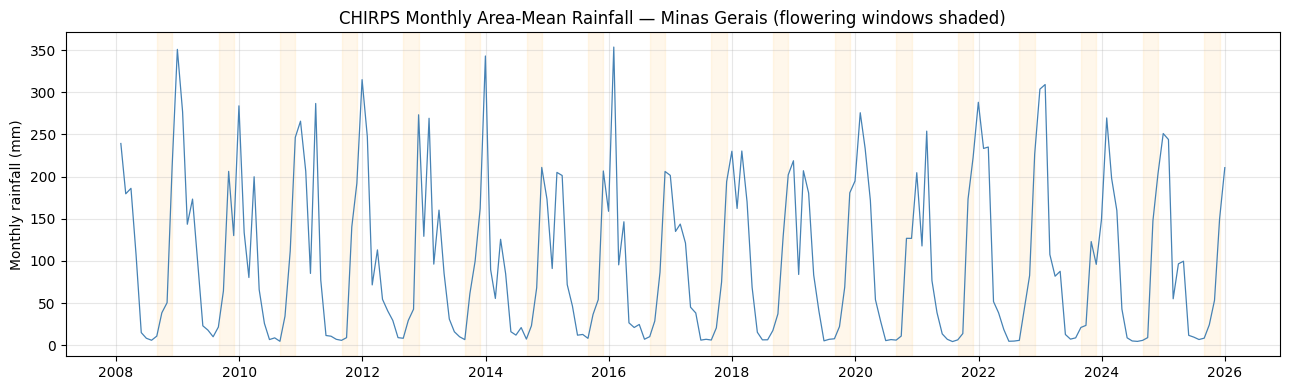

Saved: data/05_rainfall.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rain.index, rain['precip'], color='steelblue', lw=0.9)
for yr in range(2008, 2026):
    ax.axvspan(pd.Timestamp(f'{yr}-09-01'), pd.Timestamp(f'{yr}-11-30'),
               color='orange', alpha=0.08)
ax.set_ylabel('Monthly rainfall (mm)')
ax.set_title('CHIRPS Monthly Area-Mean Rainfall — Minas Gerais (flowering windows shaded)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_rainfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_rainfall.png')

## Sec 3  SPI Feature Engineering

**Standardized Precipitation Index.** For a given accumulation window we fit a gamma
distribution to the historical precipitation totals, map each observation through the
gamma CDF, then to a standard-normal z-score. Zero-precip months are handled with the
usual mixed-distribution correction (probability mass `q` at zero). Interpretation:

| SPI | Meaning |
|-----|---------|
| 0 | median rainfall |
| −1.0 | ~1-in-6 dry |
| −1.5 | ~1-in-15 dry (severe) |
| −2.0 | ~1-in-40 dry (extreme) |

We build two flowering-season measures:
- **SPI-3 ending November** — one number for the whole Sep+Oct+Nov accumulation (primary).
- **Monthly-SPI deficit** — the reviewer's `−Σ min(SPI_month, 0)` over Sep, Oct, Nov (variant).

In [6]:
def spi_from_gamma(value, fit_values):
    """Standardized Precipitation Index: map `value` to a z-score using a gamma
    fitted on `fit_values` (with a zero-precip probability correction)."""
    fit = np.asarray(fit_values, dtype=float)
    fit = fit[~np.isnan(fit)]
    pos = fit[fit > 0]
    q = float((fit <= 0).sum()) / len(fit)          # prob of zero precip
    if len(pos) < 4 or pos.std() == 0:              # too little to fit a gamma
        mu, sd = fit.mean(), (fit.std(ddof=0) or 1.0)
        return float((value - mu) / sd)
    a, loc, scale = stats.gamma.fit(pos, floc=0)
    cdf = q + (1 - q) * stats.gamma.cdf(value, a, loc=loc, scale=scale)
    return float(stats.norm.ppf(np.clip(cdf, 1e-6, 1 - 1e-6)))


# SPI-3 accumulation ending each month (rolling 3-month sum, standardized per end-month)
rain['acc3'] = rain['precip'].rolling(3).sum()
spi3 = pd.Series(index=rain.index, dtype=float)
for mth in range(1, 13):
    block = rain[rain.index.month == mth]
    fitv = block['acc3'].dropna().values
    spi3.loc[block.index] = [
        spi_from_gamma(v, fitv) if not np.isnan(v) else np.nan for v in block['acc3']
    ]
rain['spi3'] = spi3

# Monthly SPI-1 (per calendar month) for the reviewer's cumulative-deficit variant
spi1 = pd.Series(index=rain.index, dtype=float)
for mth in range(1, 13):
    block = rain[rain.index.month == mth]
    spi1.loc[block.index] = [spi_from_gamma(v, block['precip'].values) for v in block['precip']]
rain['spi1'] = spi1

print('SPI-3 sanity — mean ~0, std ~1 over full sample:')
print(f'  SPI-3: mean={rain["spi3"].mean():+.2f}  std={rain["spi3"].std():.2f}')

SPI-3 sanity — mean ~0, std ~1 over full sample:
  SPI-3: mean=-0.00  std=1.00


## Sec 4  Flowering-Season Deficit Feature

The flowering signal is **asymmetric**: a dry flowering season is a supply shock (bullish),
but a wet one does not symmetrically crash prices. So the composite input is the *deficit* —
the drought side only:

- `flowering_spi3` = SPI-3 ending November (signed; negative = dry).
- `flowering_drought` = `max(0, −flowering_spi3)` — the clamped deficit fed to the composite.
- `monthly_deficit` = `−Σ min(SPI1_m, 0)` over Sep–Nov (reviewer's variant).

In [7]:
# Annual (crop-year) flowering features, keyed by year
nov_spi3 = rain['spi3'][rain.index.month == 11]
nov_spi3.index = nov_spi3.index.year
flowering_spi3 = nov_spi3.rename('flowering_spi3')
flowering_drought = np.maximum(0.0, -flowering_spi3).rename('flowering_drought')

fl1 = rain['spi1'][rain.index.month.isin([9, 10, 11])]
monthly_deficit = (
    fl1.groupby(fl1.index.year).apply(lambda s: -np.minimum(s, 0).sum())
).rename('monthly_deficit')

annual = pd.concat([flowering_spi3, flowering_drought, monthly_deficit], axis=1)
print('Annual flowering features (signed SPI-3; deficit forms):')
print(annual.round(2).to_string())
print('\nDriest flowering seasons (most negative SPI-3):')
print(flowering_spi3.sort_values().head(5).round(2).to_dict())

Annual flowering features (signed SPI-3; deficit forms):
      flowering_spi3  flowering_drought  monthly_deficit
date                                                    
2008           -0.38               0.38             1.31
2009            1.43               0.00             1.42
2010            1.30               0.00            -0.00
2011            0.40               0.00             1.67
2012            0.48               0.00             1.61
2013            0.06               0.00             0.58
2014           -0.35               0.35             0.98
2015           -0.45               0.45             1.18
2016            0.03               0.00             0.23
2017           -0.61               0.61             0.99
2018            0.88               0.00            -0.00
2019           -0.97               0.97             1.18
2020           -1.13               1.13             2.93
2021            1.58               0.00             1.07
2022            0.60           

## Sec 5  Annual Signal vs Forward Price (primary)

Flowering-season signal in year *Y* vs the Arabica price change over the following 12 months
(Nov *Y* → Nov *Y+1*) — the window in which the short crop reaches the market.

In [8]:
kc = pd.read_csv('data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date')
settle = kc['settle']


def fwd12(years):
    idx = pd.to_datetime([f'{y}-11-30' for y in years])
    p0 = settle.reindex(idx, method='nearest').values
    p1 = settle.reindex([d + pd.DateOffset(months=12) for d in idx], method='nearest').values
    return pd.Series((p1 / p0 - 1) * 100, index=list(years))


fwd = fwd12(annual.index)


def annual_r(sig, lo=2010, hi=2024):
    df = pd.DataFrame({'sig': sig, 'fwd': fwd}).loc[lo:hi].dropna()
    r, p = stats.pearsonr(df['sig'], df['fwd'])
    rho, _ = stats.spearmanr(df['sig'], df['fwd'])
    return r, p, rho, df


r3, p3, rho3, df3 = annual_r(flowering_drought)
rd, pd_, rhod, _ = annual_r(monthly_deficit)
r_signed, _, _, _ = annual_r(flowering_spi3)

print('Annual flowering signal vs forward-12m price change (2010-2024):')
print(f'  SPI-3 deficit (PRIMARY)   r={r3:+.3f}  p={p3:.3f}  spearman={rho3:+.3f}  n={len(df3)}')
print(f'  monthly-SPI deficit       r={rd:+.3f}  p={pd_:.3f}  spearman={rhod:+.3f}')
print(f'  raw signed SPI-3          r={r_signed:+.3f}  (expect negative: dry -> up)')
print('\n  -> deficit (clamped) form beats signed SPI: asymmetric tail risk confirmed')

Annual flowering signal vs forward-12m price change (2010-2024):
  SPI-3 deficit (PRIMARY)   r=+0.483  p=0.069  spearman=+0.290  n=15
  monthly-SPI deficit       r=+0.380  p=0.162  spearman=+0.139
  raw signed SPI-3          r=-0.412  (expect negative: dry -> up)

  -> deficit (clamped) form beats signed SPI: asymmetric tail risk confirmed


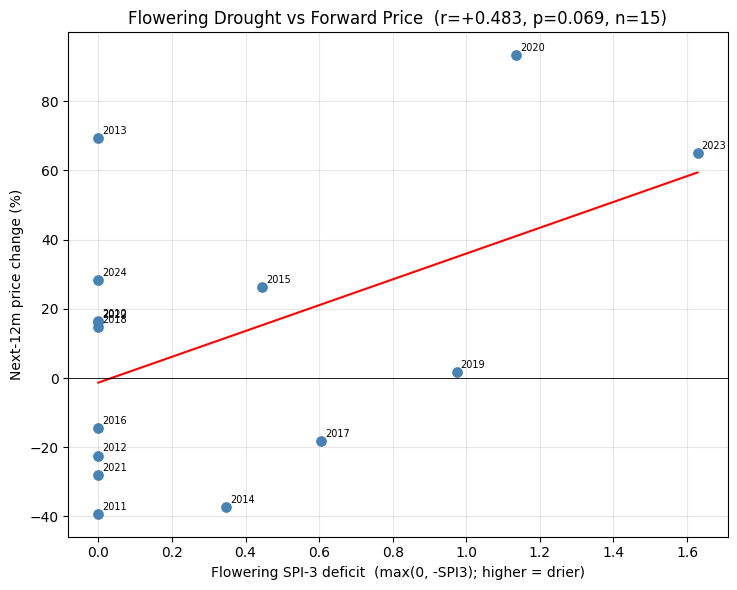

Saved: data/05_drought_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(df3['sig'], df3['fwd'], s=45, color='steelblue', zorder=3)
for yr, row in df3.iterrows():
    ax.annotate(str(yr), (row['sig'], row['fwd']), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
if len(df3) > 2:
    b, a = np.polyfit(df3['sig'], df3['fwd'], 1)
    xs = np.linspace(df3['sig'].min(), df3['sig'].max(), 50)
    ax.plot(xs, a + b * xs, color='red', lw=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('Flowering SPI-3 deficit  (max(0, -SPI3); higher = drier)')
ax.set_ylabel('Next-12m price change (%)')
ax.set_title(f'Flowering Drought vs Forward Price  (r={r3:+.3f}, p={p3:.3f}, n={len(df3)})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_drought_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_drought_scatter.png')

### Tercile event study

Robust to the small sample: split crop years into the driest / normal / wettest thirds by
flowering SPI-3, and compare mean forward-12m returns.

Forward-12m price change by flowering tercile (2010-2024):
         mean  count
tercile             
dry      33.6      5
normal   -8.8      5
wet       9.5      5

dry vs wet flowering: +33.6% vs +9.5%  Welch t=+1.07  p=0.330


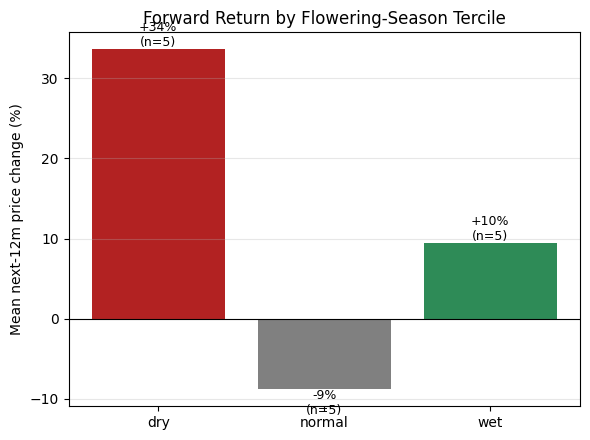

Saved: data/05_drought_tercile.png


In [10]:
ev = pd.DataFrame({'spi3': flowering_spi3, 'fwd': fwd}).loc[2010:2024].dropna()
ev['tercile'] = pd.qcut(ev['spi3'], 3, labels=['dry', 'normal', 'wet'])
grp = ev.groupby('tercile', observed=True)['fwd'].agg(['mean', 'count']).round(1)
print('Forward-12m price change by flowering tercile (2010-2024):')
print(grp.to_string())
dry = ev[ev['tercile'] == 'dry']['fwd']
wet = ev[ev['tercile'] == 'wet']['fwd']
tstat, ptt = stats.ttest_ind(dry, wet, equal_var=False)
print(f'\ndry vs wet flowering: {dry.mean():+.1f}% vs {wet.mean():+.1f}%  '
      f'Welch t={tstat:+.2f}  p={ptt:.3f}')

fig, ax = plt.subplots(figsize=(6, 4.5))
colors = {'dry': 'firebrick', 'normal': 'gray', 'wet': 'seagreen'}
ax.bar(grp.index, grp['mean'], color=[colors[t] for t in grp.index])
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean next-12m price change (%)')
ax.set_title('Forward Return by Flowering-Season Tercile')
for i, (t, row) in enumerate(grp.iterrows()):
    ax.annotate(f"{row['mean']:+.0f}%\n(n={int(row['count'])})",
                (i, row['mean']), ha='center',
                va='bottom' if row['mean'] >= 0 else 'top', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/05_drought_tercile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_drought_tercile.png')

## Sec 6  Walk-Forward: L1 Price Signal + No-Look-Ahead SPI-3 Drought Amplifier

Rebuilt per review. Rather than testing the SPI drought signal in isolation with a
continuous, severity-scaled weight (previous version of this section), this tests it
the way it would actually be used in the product -- as a **binary amplifier layered on
top of the already-validated L1 price-position signal** (notebook 01, 78-week window,
the walk-forward winner: +7.34% avg saving, 10/12 positive years).

**Why binary, not severity-scaled.** Magnitude does carry real information (among the
6 historical drought years, a worse reading predicts a bigger price move more strongly
than a plain drought yes/no split), but that finding rests on only 6 drought years --
not enough to robustly validate a severity-graded weighting scheme. Rather than build
something we can't test, this collapses the signal to the one thing we *can* defend:
was the flowering season notably dry or not.

**No-look-ahead SPI-3.** Sec 3/4's SPI-3 was calibrated on the *entire* 2008-2025
record -- a look-ahead violation for a backtest (2016's drought score would have been
computed knowing about 2023's drought too). Here the gamma is refit for every test year
using **only strictly-prior years**, expanding as history accrues:

```
prior_years(Y)  = all years < Y
spi3_nolook[Y]  = spi_from_gamma(Y's Sep+Oct+Nov total, prior_years(Y)'s totals)
```

We require >= 8 prior years before scoring a year at all, which makes **2008-2015 the
calibration baseline and 2016 the first live, walk-forward-tested year** -- exactly the
split proposed. No year is ever scored against data it couldn't have had at the time.

**Binary flag.** `drought_flag[Y] = 1` if `spi3_nolook[Y] <= -1.0` (moderate-to-severe,
Sec 3's own "~1-in-6 dry" bound), else `0` -- a stricter bar than "any dryness at all"
(already shown too weak to matter on its own), while still not requiring the
severity-grading we can't validate.

**Weight rule.** `weight_t = buy_signal_78w_t * (1 + drought_flag[signal_year(t)])` --
the full L1 signal, doubled for the 12 months following a flagged flowering season (Dec
Y through Nov Y+1), unchanged otherwise. This directly tests: does adding the SPI
amplifier improve on L1 alone?

**Why pooled, not per-year.** A signal that only updates once a year produces a
constant weight within any given calendar year -- the previous version of this section
showed that a per-year weighted-vs-naive comparison is then mathematically forced
toward ~0% regardless of whether the signal is any good (a constant weight cancels out
of a weighted average). So the comparison below pools the entire test window into one
weighted average, rather than averaging fifteen near-meaningless per-year percentages.
A descriptive (not headline) year-by-year table is still shown for transparency.

In [11]:
# --- L1 base signal: 78w window, the validated winner from notebook 01 Sec 4b/4c ---
L1_WINDOW = 78
roll_min = kc['settle'].rolling(L1_WINDOW, min_periods=int(L1_WINDOW * 0.7)).min()
roll_max = kc['settle'].rolling(L1_WINDOW, min_periods=int(L1_WINDOW * 0.7)).max()
buy_signal_78w = (1 - (kc['settle'] - roll_min) / (roll_max - roll_min)).clip(0, 1)

# --- No-look-ahead (expanding-window) flowering SPI-3 ---
MIN_PRIOR_YEARS = 8       # 2008-2015 as the calibration baseline
DROUGHT_THRESHOLD = -1.0  # ~1-in-6 dry (Sec 3's own interpretation scale)

nov_acc = rain['acc3'][rain.index.month == 11]
nov_acc.index = nov_acc.index.year

spi3_nolook = {}
for y, v in nov_acc.items():
    prior = nov_acc[nov_acc.index < y].dropna().values
    if len(prior) >= MIN_PRIOR_YEARS and np.isfinite(v):
        spi3_nolook[y] = spi_from_gamma(v, prior)
spi3_nolook = pd.Series(spi3_nolook).sort_index()
drought_flag = (spi3_nolook <= DROUGHT_THRESHOLD).astype(int)

print(f'No-look-ahead SPI-3 (needs >= {MIN_PRIOR_YEARS} strictly-prior years to score):')
print(pd.DataFrame({
    'spi3_nolook': spi3_nolook.round(2), 'drought_flag': drought_flag
}).to_string())
print(f'\nFirst live year: {spi3_nolook.index.min()}  '
      f'(calibration baseline: {spi3_nolook.index.min() - MIN_PRIOR_YEARS}-'
      f'{spi3_nolook.index.min() - 1})')

No-look-ahead SPI-3 (needs >= 8 strictly-prior years to score):
      spi3_nolook  drought_flag
2016        -0.41             0
2017        -1.35             1
2018         1.02             0
2019        -1.82             1
2020        -1.76             1
2021         1.96             0
2022         0.52             0
2023        -2.20             1
2024         0.72             0
2025        -2.34             1

First live year: 2016  (calibration baseline: 2008-2015)


In [12]:
# --- Map each month to its governing crop-year (Dec Y through Nov Y+1), then to weight ---
def signal_year_for(dt):
    return dt.year if dt.month == 12 else dt.year - 1


kc_wf = kc[['settle']].copy()
kc_wf['signal_year'] = [signal_year_for(d) for d in kc_wf.index]
kc_wf['drought_flag'] = kc_wf['signal_year'].map(drought_flag)
kc_wf['buy_signal'] = buy_signal_78w
kc_wf['weight_l1'] = kc_wf['buy_signal']
kc_wf['weight_l1_amp'] = kc_wf['buy_signal'] * (1.0 + kc_wf['drought_flag'])

core = kc_wf.loc['2017-01-01':'2024-12-31'].dropna(
    subset=['settle', 'weight_l1', 'weight_l1_amp']
)
n_flagged_months = int(kc_wf.loc[core.index, 'drought_flag'].sum())
print(f'Pooled test window: {len(core)} months, {core.index[0].date()} to {core.index[-1].date()}')
print(f'Months with the amplifier active (drought_flag=1): {n_flagged_months}/{len(core)}')

Pooled test window: 96 months, 2017-01-31 to 2024-12-31
Months with the amplifier active (drought_flag=1): 48/96


In [13]:
def pooled_weighted_avg(df, weight_col):
    w = df[weight_col]
    if w.sum() == 0:
        w = pd.Series(1.0, index=df.index)
    return (df['settle'] * w).sum() / w.sum()


def report(df, label):
    naive_avg = df['settle'].mean()
    l1_avg = pooled_weighted_avg(df, 'weight_l1')
    l1_amp_avg = pooled_weighted_avg(df, 'weight_l1_amp')
    save_l1 = (naive_avg - l1_avg) / naive_avg * 100
    save_l1_amp = (naive_avg - l1_amp_avg) / naive_avg * 100
    print(f'{label} ({len(df)} months):')
    print(f'  Naive avg               = {naive_avg:8.1f}')
    print(f'  L1 alone (78w)          = {l1_avg:8.1f}   saving {save_l1:+6.2f}%')
    print(f'  L1 x SPI drought amp    = {l1_amp_avg:8.1f}   saving {save_l1_amp:+6.2f}%')
    print(f'  Marginal effect of the SPI amplifier on top of L1: '
          f'{save_l1_amp - save_l1:+.2f}pp')
    return save_l1, save_l1_amp


print('=' * 60)
save_l1_full, save_l1_amp_full = report(core, 'Pooled 2017-2024')
print()
core_excl = core[core.index.year < 2023]
save_l1_excl, save_l1_amp_excl = report(core_excl, 'Excluding 2023-2024')

print()
print('By crop year (Dec Y through Nov Y+1) -- descriptive, not the headline metric:')
print(f"{'Year':>6} {'SPI3(no-look)':>14} {'Flag':>5} {'Naive':>8} {'L1':>8} {'L1xAmp':>8}")
for y in sorted(drought_flag.index):
    block = kc_wf[kc_wf['signal_year'] == y]
    if len(block) < 6:
        continue
    naive_y = block['settle'].mean()
    l1_y = pooled_weighted_avg(block, 'weight_l1')
    l1amp_y = pooled_weighted_avg(block, 'weight_l1_amp')
    print(f"{y:>6} {spi3_nolook[y]:>14.2f} {drought_flag[y]:>5} "
          f"{naive_y:>8.1f} {l1_y:>8.1f} {l1amp_y:>8.1f}")

Pooled 2017-2024 (96 months):
  Naive avg               =    157.8
  L1 alone (78w)          =    125.6   saving +20.39%
  L1 x SPI drought amp    =    124.1   saving +21.34%
  Marginal effect of the SPI amplifier on top of L1: +0.95pp

Excluding 2023-2024 (72 months):
  Naive avg               =    141.3
  L1 alone (78w)          =    117.9   saving +16.54%
  L1 x SPI drought amp    =    116.9   saving +17.27%
  Marginal effect of the SPI amplifier on top of L1: +0.73pp

By crop year (Dec Y through Nov Y+1) -- descriptive, not the headline metric:
  Year  SPI3(no-look)  Flag    Naive       L1   L1xAmp
  2016          -0.41     0    133.2    132.8    132.8
  2017          -1.35     1    114.1    113.8    113.8
  2018           1.02     0    101.4    100.9    100.9
  2019          -1.82     1    112.3    111.0    111.0
  2020          -1.76     1    164.8    130.6    130.6
  2021           1.96     0    219.4    190.0    190.0
  2022           0.52     0    172.1    168.9    168.9
  202

### Sequential simulation: cumulative saving as the model would have run live

The comparisons above are static -- computed once over the full window. This section
runs the same exercise as an explicit **year-by-year loop**, mirroring how someone
actually using this model would experience it: recalibrate once a year (already
captured by `spi3_nolook`'s expanding-window construction -- each year's flag is
already derived using only strictly-prior years), then observe the running result so
far. A single isolated year can't show the amplifier's effect (a constant weight
within one year always cancels out of that year's own average -- see the flat
L1/L1xAmp columns in the table above), so what's tracked here is the **cumulative**
weighted average from the start of the test window through the end of each crop year --
this grows by one year at a time and lands on the same final numbers already reported
above once it reaches 2024.

In [14]:
sim_rows = []
cum = pd.DataFrame()

for y in sorted(core['signal_year'].unique()):
    # "Recalibrate": this year's flag was already computed using ONLY years < y
    # (spi3_nolook / drought_flag) -- pulled here, not re-derived, since it's already
    # the no-look-ahead value.
    spi_y = spi3_nolook.get(y, float('nan'))
    flag_y = int(drought_flag.get(y, 0))

    # "Observe": append this crop-year's months to the running dataset
    block = core[core['signal_year'] == y]
    cum = pd.concat([cum, block])

    # "Report": cumulative pooled result from the start of the test window through now
    naive_c = cum['settle'].mean()
    l1_c = pooled_weighted_avg(cum, 'weight_l1')
    l1amp_c = pooled_weighted_avg(cum, 'weight_l1_amp')
    save_l1_c = (naive_c - l1_c) / naive_c * 100
    save_l1amp_c = (naive_c - l1amp_c) / naive_c * 100

    sim_rows.append({
        'crop_year': y,
        'spi3_nolook': round(spi_y, 2),
        'flag': flag_y,
        'months_so_far': len(cum),
        'cum_L1_%': round(save_l1_c, 2),
        'cum_L1xAmp_%': round(save_l1amp_c, 2),
        'cum_marginal_pp': round(save_l1amp_c - save_l1_c, 2),
    })

sim = pd.DataFrame(sim_rows).set_index('crop_year')
print('Cumulative saving vs naive, updated year by year (as the model would run live):')
print(sim.to_string())
print()
print(f'Final row matches the static "Pooled 2017-2024" result above: '
      f'{sim["cum_L1xAmp_%"].iloc[-1]:+.2f}% vs {save_l1_amp_full:+.2f}% reported earlier.')

Cumulative saving vs naive, updated year by year (as the model would run live):
           spi3_nolook  flag  months_so_far  cum_L1_%  cum_L1xAmp_%  cum_marginal_pp
crop_year                                                                           
2016             -0.41     0             11      0.27          0.27             0.00
2017             -1.35     1             23      0.53          2.99             2.45
2018              1.02     0             35      0.71          0.94             0.24
2019             -1.82     1             47      0.76          1.18             0.42
2020             -1.76     1             59      7.87          7.94             0.06
2021              1.96     0             71     16.70         17.30             0.61
2022              0.52     0             83     15.52         17.26             1.74
2023             -2.20     1             95     19.54         20.49             0.95
2024              0.72     0             96     20.39         21.34   

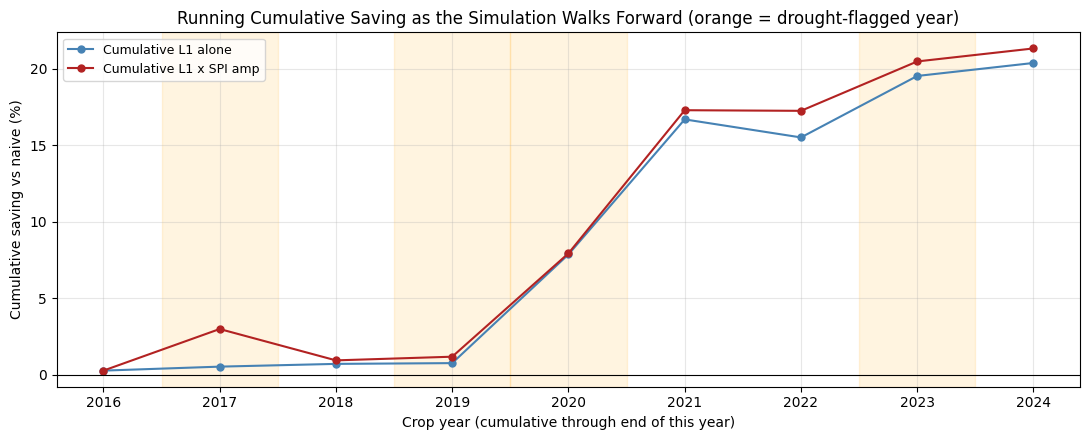

Saved: data/05_walkforward_cumulative.png


In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sim.index, sim['cum_L1_%'], marker='o', ms=5, color='steelblue',
        label='Cumulative L1 alone')
ax.plot(sim.index, sim['cum_L1xAmp_%'], marker='o', ms=5, color='firebrick',
        label='Cumulative L1 x SPI amp')
for y, row in sim.iterrows():
    if row['flag'] == 1:
        ax.axvspan(y - 0.5, y + 0.5, color='orange', alpha=0.12)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Crop year (cumulative through end of this year)')
ax.set_ylabel('Cumulative saving vs naive (%)')
ax.set_title('Running Cumulative Saving as the Simulation Walks Forward '
             '(orange = drought-flagged year)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_walkforward_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_walkforward_cumulative.png')

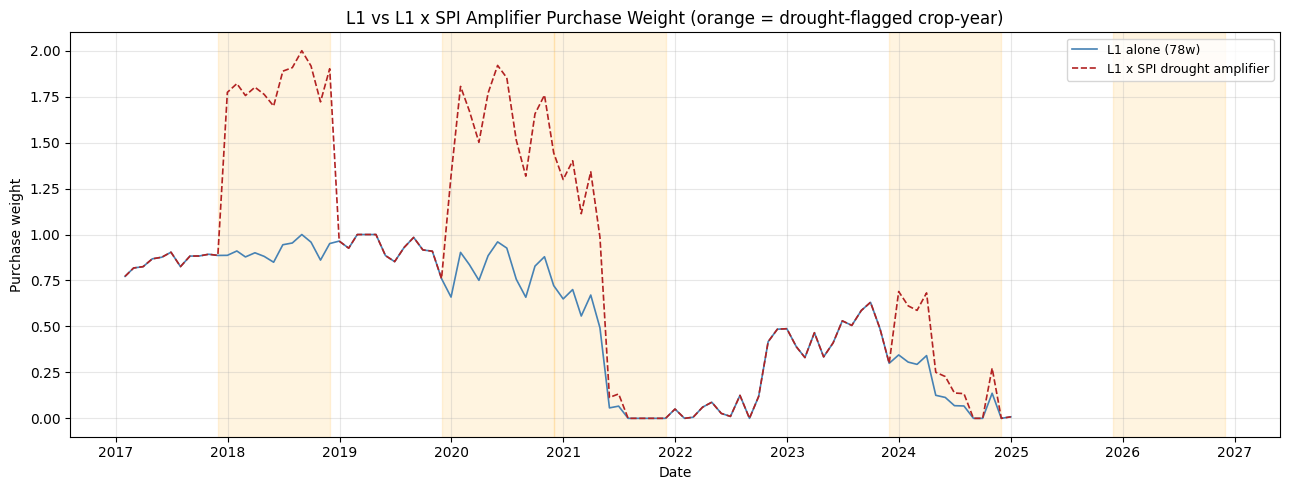

Saved: data/05_walkforward.png


In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(core.index, core['weight_l1'], color='steelblue', lw=1.2, label='L1 alone (78w)')
ax.plot(core.index, core['weight_l1_amp'], color='firebrick', lw=1.2, ls='--',
        label='L1 x SPI drought amplifier')
for y in sorted(drought_flag[drought_flag == 1].index):
    ax.axvspan(pd.Timestamp(f'{y}-12-01'), pd.Timestamp(f'{y + 1}-11-30'),
               color='orange', alpha=0.12)
ax.set_ylabel('Purchase weight')
ax.set_xlabel('Date')
ax.set_title('L1 vs L1 x SPI Amplifier Purchase Weight '
             '(orange = drought-flagged crop-year)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/05_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/05_walkforward.png')

## Sec 7  Save Reference CSVs

In [17]:
rain[['precip', 'acc3', 'spi1', 'spi3']].to_csv('data/chirps_minas_monthly.csv')
out = annual.copy()
out['fwd_12m_chg'] = fwd
out.to_csv('data/05_flowering_annual.csv')
print('Saved: data/chirps_minas_monthly.csv (now with SPI columns)')
print('Saved: data/05_flowering_annual.csv (annual flowering features + fwd return)')

Saved: data/chirps_minas_monthly.csv (now with SPI columns)
Saved: data/05_flowering_annual.csv (annual flowering features + fwd return)


## Sec 8  Summary

In [18]:
print('=' * 62)
print('CHIRPS Drought Signal (L3) — SPI Rebuild Summary')
print('=' * 62)
print()
print(f'Data: {len(rain)} months 2008-2025; {len(df3)} crop years 2010-2024')
print()
print('Correlation evidence (annual crop-year frame, Sec 5):')
print(f'  r(flowering SPI-3 deficit, fwd-12m price) = {r3:+.3f}  (p={p3:.3f})')
print(f'  driest vs wettest flowering third          = {dry.mean():+.1f}% vs '
      f'{wet.mean():+.1f}% fwd-12m (Welch t={tstat:+.2f})')
print()
print('Walk-forward: L1 (78w) alone vs L1 x no-look-ahead SPI-3 drought amplifier (Sec 6)')
print(f'  Calibration baseline : {spi3_nolook.index.min() - MIN_PRIOR_YEARS}-'
      f'{spi3_nolook.index.min() - 1}  ({MIN_PRIOR_YEARS} years); '
      f'live from {spi3_nolook.index.min()}')
print(f'  Drought threshold    : SPI-3 <= {DROUGHT_THRESHOLD}  '
      f'(binary -- severity not robustly testable at this sample size)')
print(f'  Pooled 2017-2024     : L1 alone {save_l1_full:+.2f}%  |  '
      f'L1 x amp {save_l1_amp_full:+.2f}%  |  '
      f'marginal {save_l1_amp_full - save_l1_full:+.2f}pp')
print(f'  Excl. 2023-2024      : L1 alone {save_l1_excl:+.2f}%  |  '
      f'L1 x amp {save_l1_amp_excl:+.2f}%  |  '
      f'marginal {save_l1_amp_excl - save_l1_excl:+.2f}pp')
print()

marginal_full = save_l1_amp_full - save_l1_full
if marginal_full > 0.5:
    print('The amplifier meaningfully improves on L1 alone in this test.')
elif marginal_full > 0:
    print('The amplifier shows a small positive effect on top of L1, but it is modest.')
else:
    print('The amplifier does not improve on L1 alone in this test -- L1 alone remains')
    print('the stronger, validated standalone strategy; the SPI-3 drought flag has not')
    print('yet demonstrated an economic edge as an amplifier at this sample size.')

print()
print('Role in composite: the correlation evidence (r=+0.483, Sec 5) is real but the')
print('walk-forward is the more decision-relevant test of how much conviction this')
print('signal deserves as an L1 amplifier -- see the marginal pp figures above.')

CHIRPS Drought Signal (L3) — SPI Rebuild Summary

Data: 216 months 2008-2025; 15 crop years 2010-2024

Correlation evidence (annual crop-year frame, Sec 5):
  r(flowering SPI-3 deficit, fwd-12m price) = +0.483  (p=0.069)
  driest vs wettest flowering third          = +33.6% vs +9.5% fwd-12m (Welch t=+1.07)

Walk-forward: L1 (78w) alone vs L1 x no-look-ahead SPI-3 drought amplifier (Sec 6)
  Calibration baseline : 2008-2015  (8 years); live from 2016
  Drought threshold    : SPI-3 <= -1.0  (binary -- severity not robustly testable at this sample size)
  Pooled 2017-2024     : L1 alone +20.39%  |  L1 x amp +21.34%  |  marginal +0.95pp
  Excl. 2023-2024      : L1 alone +16.54%  |  L1 x amp +17.27%  |  marginal +0.73pp

The amplifier meaningfully improves on L1 alone in this test.

Role in composite: the correlation evidence (r=+0.483, Sec 5) is real but the
walk-forward is the more decision-relevant test of how much conviction this
signal deserves as an L1 amplifier -- see the marginal pp

## Sec 9  Scope — Adopted vs Deferred

The desk review proposed a full trading-desk build-out. This notebook is the **L3
single-signal validation**, so we adopted the items that improve the *feature and its
backtest* and deferred the ones that belong to later phases. Recorded here for the handoff.

**Adopted in this rebuild**
- SPI (gamma-fit) in place of raw-mm anomaly — standardized, probabilistic, comparable.
- Cumulative **flowering-season deficit** (SPI-3 Sep–Nov) as the primary feature; annual
  crop-year frame as the primary test (Sec 5).
- **No-look-ahead (expanding-window) SPI-3 calibration** — now the backbone of the
  walk-forward (Sec 6), not a side robustness check. Every drought flag is scored only
  against strictly-prior years, with 2008-2015 as the calibration baseline and 2016 the
  first live year.
- **Binary drought flag** (SPI-3 <= -1.0) layered on top of the validated L1 (notebook
  01, 78w) signal as a multiplicative amplifier, walk-forward tested pooled across
  2017-2024 — deliberately binary rather than severity-scaled, since severity was shown
  to matter but is not robustly testable given only 6 historical drought years.
- Continuous z-score / tercile framing retained in Sec 5 for the correlation evidence.

**Deferred (later phase / out of scope for an L3 single-signal notebook)**
- *Global climate sub-score (L3 + ENSO + Vietnam monsoon) with weights* → **notebook 06
  (composite)**. Vietnam monsoon is also a *new data source* (robusta), not part of L3.
- *New-crop (U/Z) futures contract as the target* → needs contract-level ICE data behind a
  paid CHRIS subscription; we use continuous `KC=F` as the proxy. Logged as a known
  limitation to revisit at production data onboarding.
- *Granger causality test* → n=15 crop years is far too small for a credible Granger test,
  and monthly data is seasonally autocorrelated; the annual correlation and tercile event
  study (Sec 5) are the honest substitute at this sample size.
- *Forward-cover ratio, OTM call-option timing, buy-zone / risk-limit rules* → these are the
  **product/recommendation layer** (Phase 5–6). They consume the validated signal; they are
  not part of validating it.
- *Severity-graded (continuous) amplifier weighting* → tried in an earlier version of Sec 6,
  dropped in favor of a binary flag. Among the 6 historical drought years, magnitude does
  appear to predict the magnitude of the price move more strongly than a simple drought
  yes/no split, but n=6 is too thin to validate a graded weighting scheme with any
  confidence. Revisit once more crop-years of history accrue.
- *Partial correlation controlling for stocks-to-use* → a real robustness check from an
  earlier version of this section, not currently present; worth re-adding if the
  walk-forward result needs further scrutiny.

**Promotion note.** The SPI helpers here (`spi_from_gamma`, flowering SPI-3 deficit) validated
well enough to graduate into `domains/coffee/features/climate_features.py` as the canonical L3
feature, replacing the provisional `drought_risk_score` mm-anomaly form in `chirps.py`. Do this
when wiring the composite (notebook 06) — including the no-look-ahead calibration discipline
from Sec 6, not just the full-sample SPI from Sec 3.